## Decision Tree Assignment-2

### You are a data scientist working for a healthcare company, and you have been tasked with creating a decision tree to help identify patients with diabetes based on a set of clinical variables. You have been given a dataset (diabetes.csv) with the following variables:
1. Pregnancies: Number of times pregnant (integer)
2. Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test (integer)
3. BloodPressure: Diastolic blood pressure (mm Hg) (integer)
4. SkinThickness: Triceps skin fold thickness (mm) (integer)
5. Insulin: 2-Hour serum insulin (mu U/ml) (integer)
6. BMI: Body mass index (weight in kg/(height in m)^2) (float)
7. DiabetesPedigreeFunction: Diabetes pedigree function (a function which scores likelihood of diabetes
based on family history) (float)
8. Age: Age in years (integer)
9. Outcome: Class variable (0 if non-diabetic, 1 if diabetic) (integer)


Your goal is to create a decision tree to predict whether a patient has diabetes based on the other
variables.

* Q1. Import the dataset and examine the variables. Use descriptive statistics and visualizations to
understand the distribution and relationships between the variables.
* Q2. Preprocess the data by cleaning missing values, removing outliers, and transforming categorical
variables into dummy variables if necessary.
* Q3. Split the dataset into a training set and a test set. Use a random seed to ensure reproducibility.
* Q4. Use a decision tree algorithm, such as ID3 or C4.5, to train a decision tree model on the training set. Use
* cross-validation to optimize the hyperparameters and avoid overfitting.
* Q5. Evaluate the performance of the decision tree model on the test set using metrics such as accuracy,
precision, recall, and F1 score. Use confusion matrices and ROC curves to visualize the results.
* Q6. Interpret the decision tree by examining the splits, branches, and leaves. Identify the most important
variables and their thresholds. Use domain knowledge and common sense to explain the patterns and
trends.
* Q7. Validate the decision tree model by applying it to new data or testing its robustness to changes in the
dataset or the environment. Use sensitivity analysis and scenario testing to explore the uncertainty and
risks.





In [3]:
# Import the necessary packages here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
diabetes_df = pd.read_csv(r"DataSource\diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## EDA

In [8]:
# Shape of the df
diabetes_df.shape

(768, 9)

In [7]:
# Basic info about the dataset
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
# Find if there is any missing value present
diabetes_df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
# Find duplicates
diabetes_df.duplicated().sum()

0

In [13]:
# So we don't have any duplicates as well as missing values in the dataset. All the features are numerical so
# no need to perform encoding techniques.

In [12]:
# Find the basic summary of the dataset
diabetes_df.describe() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

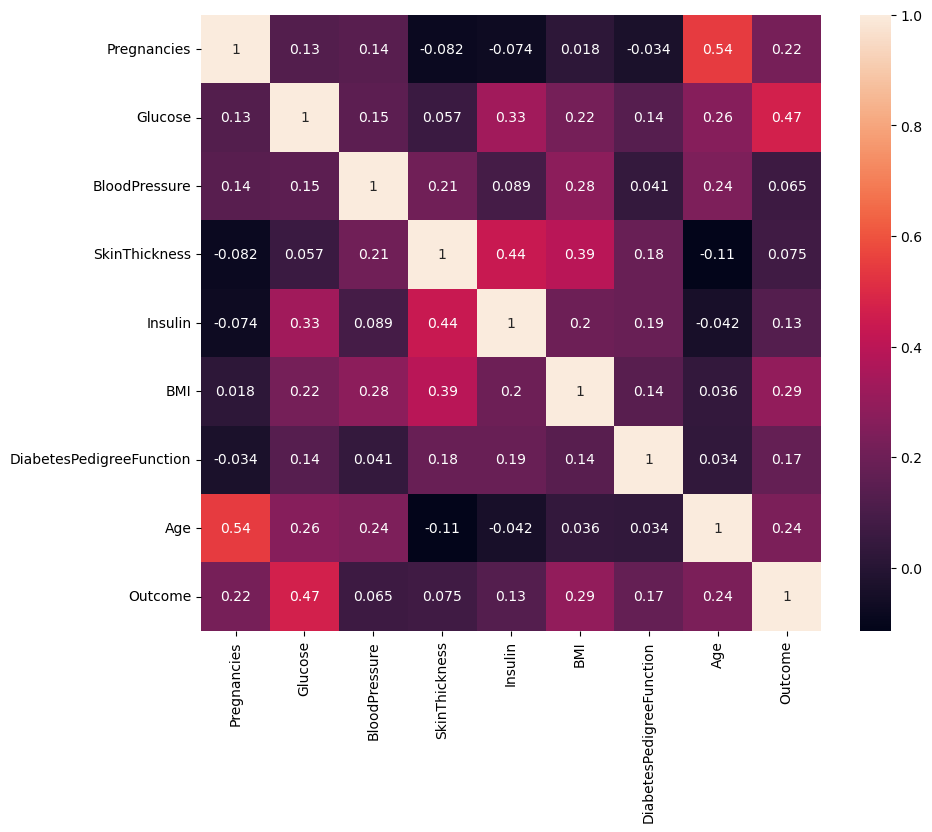

In [16]:
# Perform a heatmap to see the correlation between features
plt.figure(figsize=(10,8))
sns.heatmap(diabetes_df.corr(), annot= True)

<Axes: >

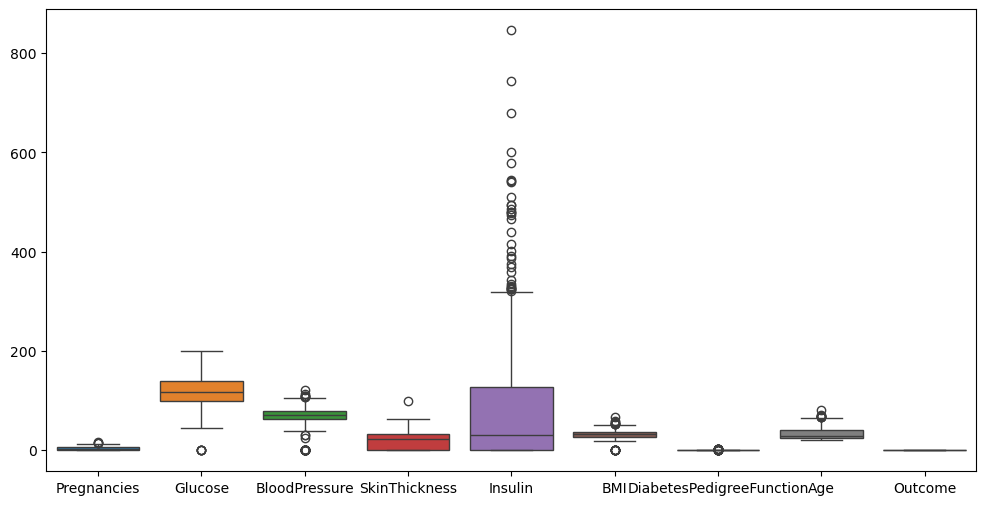

In [19]:
# Show the outliers
plt.figure(figsize=(12,6))
sns.boxplot(diabetes_df)

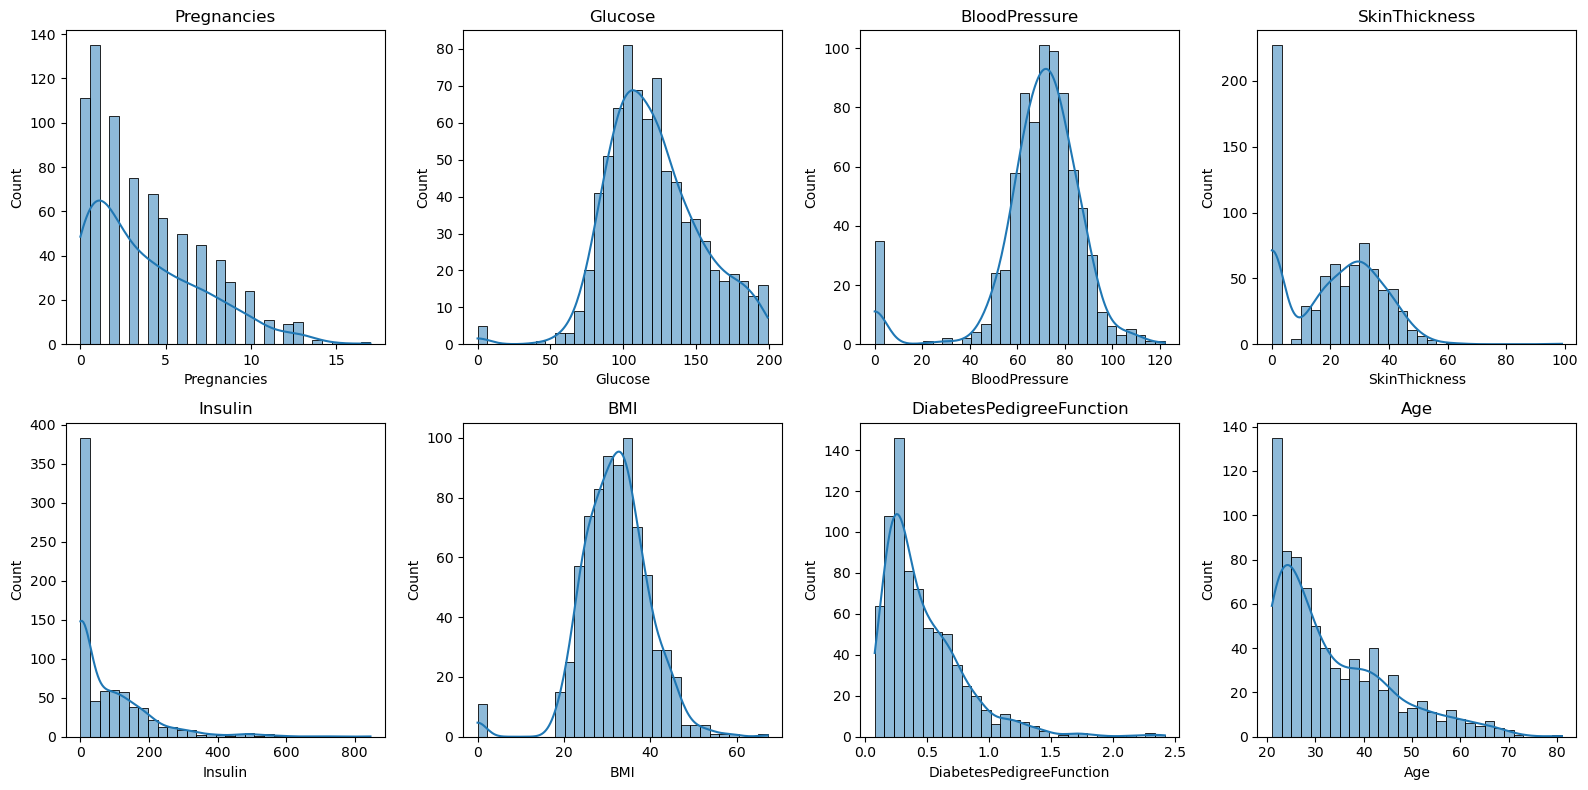

In [22]:
# Show the distributions
# Drop the outcome column (if it exists)
features = diabetes_df.drop(columns=["Outcome"], errors='ignore')  # Ignore if Outcome doesn't exist

# Set up the figure and subplots
num_features = len(features.columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))  # Adjust grid based on num of features
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot each feature
for i, col in enumerate(features.columns):
    sns.histplot(diabetes_df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

# Adjust layout
plt.tight_layout()
plt.show()

In [31]:
# Check the Outcome column
diabetes_df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20164\724642346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=diabetes_df, palette=['blue', 'orange'])


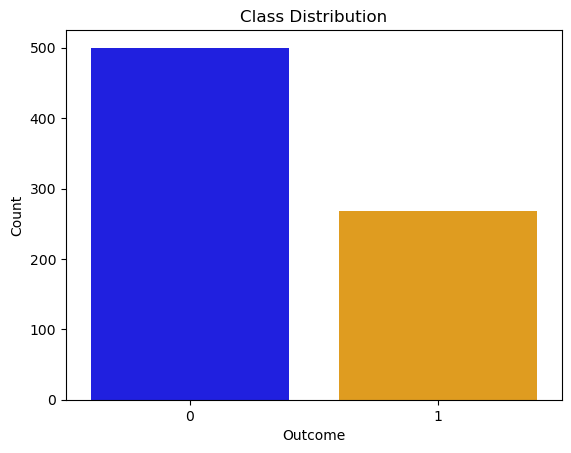

In [35]:
# Show the imbalance data
sns.countplot(x='Outcome', data=diabetes_df, palette=['blue', 'orange'])
plt.title('Class Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()


In [28]:
# Q3. Split the dataset into a training set and a test set. Use a random seed to ensure reproducibility.

from sklearn.model_selection import train_test_split

X, y = diabetes_df.drop(columns=["Outcome"]), diabetes_df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state= 42)

In [29]:
X_train.shape, X_test.shape

((537, 8), (231, 8))

In [30]:
y_train.shape, y_test.shape

((537,), (231,))

In [37]:
# Q4. Use a decision tree algorithm, such as ID3 or C4.5, to train a decision tree model on the training set. Use
# cross-validation to optimize the hyperparameters and avoid overfitting.

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
model  = DecisionTreeClassifier(class_weight='balanced', random_state = 42)

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],  
    'max_depth': [3, 5, 10, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 5],  
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit to training data
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.7504672897196262


In [38]:
# Q5. Evaluate the performance of the decision tree model on the test set using metrics such as accuracy,
# precision, recall, and F1 score. Use confusion matrices and ROC curves to visualize the results.


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.77      0.77       151
           1       0.57      0.59      0.58        80

    accuracy                           0.71       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.71      0.71      0.71       231

Accuracy: 0.7056
Precision: 0.5732
Recall: 0.5875
F1 Score: 0.5802


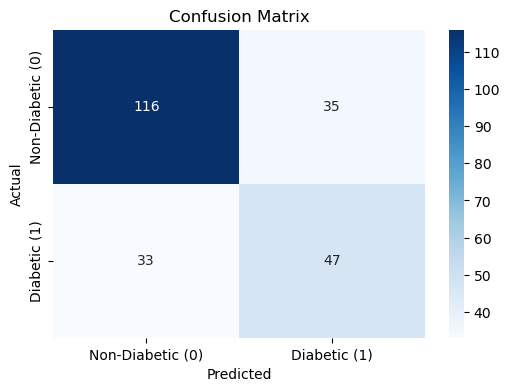

In [39]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'], yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


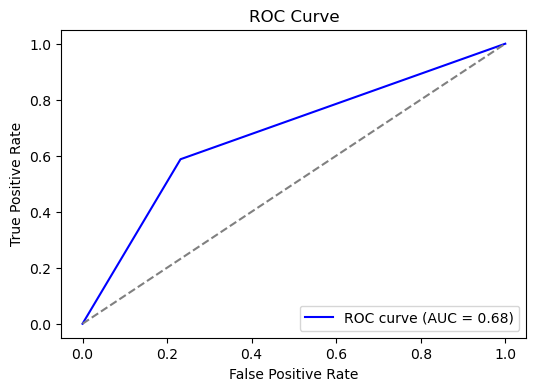

In [40]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


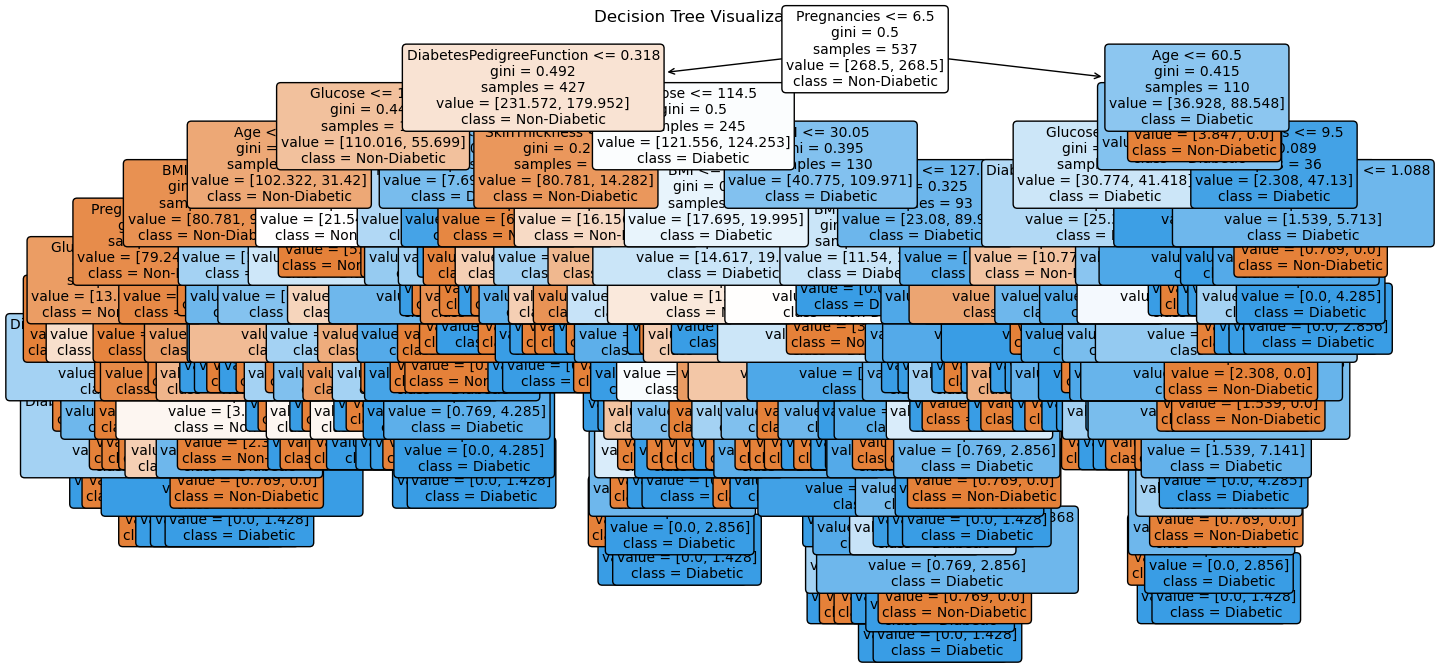

In [41]:
# Q6. Interpret the decision tree by examining the splits, branches, and leaves. Identify the most important
# variables and their thresholds. Use domain knowledge and common sense to explain the patterns and
# trends.


from sklearn.tree import plot_tree

# Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(best_model, feature_names=X_train.columns, class_names=['Non-Diabetic', 'Diabetic'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_20164\398266691.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')


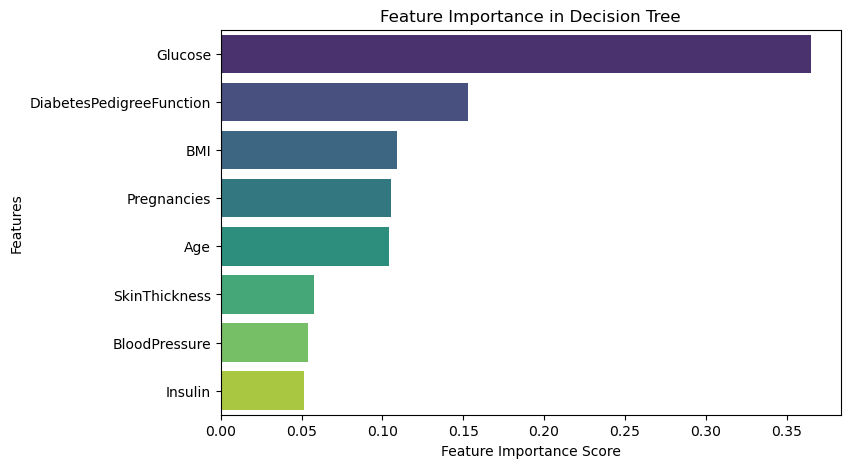

In [42]:
# Identifying the most important feature

# Extract feature importance
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Decision Tree')
plt.show()

In [43]:
# Analyzing Decision Rules & Thresholds

from sklearn.tree import export_text

# Extract decision rules
tree_rules = export_text(best_model, feature_names=list(X_train.columns))
print(tree_rules)


|--- Pregnancies <= 6.50
|   |--- DiabetesPedigreeFunction <= 0.32
|   |   |--- Glucose <= 144.50
|   |   |   |--- Age <= 30.50
|   |   |   |   |--- BMI <= 41.95
|   |   |   |   |   |--- Pregnancies <= 0.50
|   |   |   |   |   |   |--- Glucose <= 110.00
|   |   |   |   |   |   |   |--- Glucose <= 80.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Glucose >  80.00
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  110.00
|   |   |   |   |   |   |   |--- Age <= 21.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Age >  21.50
|   |   |   |   |   |   |   |   |--- DiabetesPedigreeFunction <= 0.18
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- DiabetesPedigreeFunction >  0.18
|   |   |   |   |   |   |   |   |   |--- Glucose <= 116.00
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- Glucose >  116.00
|   |  

In [44]:
# Common Sense
# Glucose is the strongest predictor: High glucose levels indicate diabetes risk.
# BMI matters: High BMI increases the chance of diabetes.
# Age & Insulin levels contribute: Older individuals with abnormal insulin levels have higher risk.